In [6]:
pip install opendatasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
final_df=pd.read_csv('D:\CA_content\Python\Final_Project\Final_Cleaned_Dataset_with_sorting.csv')

<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
C:\Users\asus\AppData\Local\Temp\ipykernel_28636\2565548412.py:5: SyntaxWarning: invalid escape sequence '\C'
  final_df=pd.read_csv('D:\CA_content\Python\Final_Project\Final_Cleaned_Dataset_with_sorting.csv')


In [2]:
# Convert text to actual Date-Time object
final_df['event_time'] = pd.to_datetime(final_df['event_time'])
# Missing brands ko ek category bana do taaki nunique() sahi se kaam kare
final_df['brand_filled'] = final_df['brand_filled'].fillna('unknown_brand')

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display

print("⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...")

# ==========================================
# STEP 1: DATA CLEANING (Remove Bots & Bounces)
# ==========================================
print("🧹 1. Cleaning Bots and Accidental Bouncers...")
session_stats = final_df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max'),
    total_events=('event_type', 'count')
).reset_index()

session_stats['total_duration_sec'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds()

# Filters
bounce_condition = (session_stats['total_events'] == 1) | (session_stats['total_duration_sec'] < 5)
views_per_minute = session_stats['total_events'] / ((session_stats['total_duration_sec'] + 1) / 60)
bot_condition = (views_per_minute > 30) & (session_stats['total_events'] > 15)

# Extract only valid human sessions
valid_sessions = session_stats[~(bounce_condition | bot_condition)]['user_session']
clean_df = final_df[final_df['user_session'].isin(valid_sessions)].copy()

print(f"✅ Data Cleaned! Kept {len(valid_sessions):,} Valid Human Sessions out of {len(session_stats):,}.")

final_df = clean_df  # Purane final_df ko saaf data se overwrite kar diya
del clean_df         # Extra variable ko delete kar diya
import gc
gc.collect()         # Python ko bola ki RAM turant free (flush) kar de!

⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...
🧹 1. Cleaning Bots and Accidental Bouncers...
✅ Data Cleaned! Kept 871,859 Valid Human Sessions out of 1,378,222.


20

In [7]:
final_df.tail()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
6727443,2019-11-16 19:03:20+00:00,view,6501081,2053013554155487563,computers.components.motherboard,gigabyte,45.05,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,gigabyte,19
6727444,2019-11-16 19:03:39+00:00,view,6500828,2053013554155487563,computers.components.motherboard,asus,80.06,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,asus,19
6727445,2019-11-16 19:03:58+00:00,view,6500974,2053013554155487563,computers.components.motherboard,asrock,82.11,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.motherboard,asrock,19
6727446,2019-11-16 19:06:10+00:00,view,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.memory,geil,19
6727447,2019-11-16 19:06:17+00:00,cart,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.memory,geil,19


In [6]:
final_df.isnull().sum()/len(final_df)

event_time              0.000000
event_type              0.000000
product_id              0.000000
category_id             0.000000
category_code           0.324559
brand                   0.137842
price                   0.000000
user_id                 0.000000
user_session            0.000000
category_code_filled    0.324559
brand_filled            0.000000
hour                    0.000000
dtype: float64

In [11]:

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    f1_score, recall_score, precision_score, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, Masking,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences

# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'✅ GPU Active: {[g.name for g in gpus]}')
    except RuntimeError as e:
        print(f'GPU config error: {e}')
else:
    print('⚠️ No GPU found — running on CPU')

sns.set_theme(style='whitegrid')
GRU_OUTPUT_DIR = 'output_Pure_GRU'
os.makedirs(GRU_OUTPUT_DIR, exist_ok=True)

✅ GPU Active: ['/physical_device:GPU:0']


In [12]:
import os
from tensorflow.keras.models import load_model

# 1. Define the directory where you saved it
GRU_OUTPUT_DIR = 'output_Pure_GRU'
extractor_path = os.path.join(GRU_OUTPUT_DIR, 'gru_embedding_extractor.keras')

# 2. Load the embedding extractor
print("⏳ Loading GRU Embedding Extractor...")
embedding_extractor = load_model(extractor_path)
print("✅ Extractor Loaded Successfully!")

# 3. Optional: Verify the architecture (It should end at your 32-dim layer)
embedding_extractor.summary()

⏳ Loading GRU Embedding Extractor...
✅ Extractor Loaded Successfully!


Model: "GRU_Embedding_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 15, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 15, 2)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 15, 2)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 15)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_1 (GRU)   │ (None, 15, 64)    │     13,056 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 15, 64)    │        256 │ gru_layer_1[0][0… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_2 (GRU)   │ (None, 32)        │      9,408 │ batch_normalizat… │
│                     │                   │            │ any[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,720 (88.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 22,720 (88.75 KB)

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import display
import pickle

print("⚙️ STEP 1: PRE-PROCESSING RAW final_df...")

clean_df = final_df.copy()

# Category extraction
clean_df['category_code'] = clean_df['category_code'].fillna('UNKNOWN')
categories = clean_df['category_code'].str.split('.', n=2, expand=True)
clean_df['category_1'] = categories[0]

# ── NEW: Fill brand missing values ──────────────────────────────────
clean_df['brand_filled'] = clean_df['brand'].fillna('UNKNOWN_BRAND')

# Target flags
clean_df['is_view']     = (clean_df['event_type'] == 'view').astype(np.int8)
clean_df['is_cart']     = (clean_df['event_type'] == 'cart').astype(np.int8)
clean_df['is_purchase'] = (clean_df['event_type'] == 'purchase').astype(np.int8)

purchase_sessions = set(clean_df[clean_df['event_type'] == 'purchase']['user_session'])
clean_df['target_purchase'] = clean_df['user_session'].isin(purchase_sessions).astype(np.int8)

# Offset calculation
clean_df = clean_df.sort_values(by=['user_session', 'event_time'])
clean_df['session_start_time']   = clean_df.groupby('user_session')['event_time'].transform('min')
clean_df['event_offset_seconds'] = (clean_df['event_time'] - clean_df['session_start_time']).dt.total_seconds()

print("✅ Pre-processing complete!\n")

# ====================================================================

print("📸 STEP 2: Capturing ANTI-LEAKAGE Time-Travel Snapshots (Tabular + GRU)...")

with open('output_Pure_GRU/gru_price_scaler.pkl', 'rb') as f:
    price_scaler = pickle.load(f)

snapshot_intervals_seconds = [84, 165, 296, 611, 1084]
snapshot_dfs = []
MAX_STEPS = 15

for snapshot_time in snapshot_intervals_seconds:
    print(f"   -> Capturing State at T = {int(snapshot_time)} seconds...")

    temp_df = clean_df[clean_df['event_offset_seconds'] <= snapshot_time].copy()

    if temp_df.empty:
        continue

    # ==========================================
    # PART A: XGBOOST TABULAR FEATURES
    # ==========================================
    snapshot_grouped = temp_df.groupby('user_session').agg(
        total_views_so_far   = ('is_view', 'sum'),
        unique_products_seen = ('product_id', 'nunique'),
        unique_cat1_seen     = ('category_1', 'nunique'),
        max_price_seen       = ('price', 'max'),
        min_price_seen       = ('price', 'min'),
        avg_price_seen       = ('price', 'mean'),
        last_action_offset   = ('event_offset_seconds', 'max'),
        target_purchase      = ('target_purchase', 'max'),
        # ── NEW: Brand diversity features ──────────────────────────
        brand_switches       = ('brand_filled', 'nunique'),
    )

    snapshot_grouped['duration_so_far_seconds']    = snapshot_time
    snapshot_grouped['live_focus_ratio']           = snapshot_grouped['total_views_so_far'] / snapshot_grouped['unique_products_seen'].replace(0, 1)
    snapshot_grouped['budget_exploration_so_far']  = np.clip(snapshot_grouped['max_price_seen'] - snapshot_grouped['min_price_seen'], 0, 1000)
    snapshot_grouped['rolling_views_per_minute']   = snapshot_grouped['total_views_so_far'] / (snapshot_time / 60)
    snapshot_grouped['idle_time_seconds']          = snapshot_time - snapshot_grouped['last_action_offset']
    snapshot_grouped['snapshot_label']             = f"{int(snapshot_time)}s"

    # ── NEW: Category focus score (1 category = focused buyer) ─────
    # Higher value = more scattered browsing = lower intent
    snapshot_grouped['category_scatter_ratio'] = (
        snapshot_grouped['unique_cat1_seen'] /
        snapshot_grouped['unique_products_seen'].replace(0, 1)
    )

    # ── NEW: Unknown category ratio (data quality signal) ──────────
    unknown_counts = (
        temp_df[temp_df['category_1'] == 'UNKNOWN']
        .groupby('user_session')
        .size()
        .rename('unknown_cat_count')
    )
    total_counts = temp_df.groupby('user_session').size().rename('total_events')

    snapshot_grouped = snapshot_grouped.join(unknown_counts).join(total_counts)
    snapshot_grouped['unknown_cat_ratio'] = (
        snapshot_grouped['unknown_cat_count'].fillna(0) /
        snapshot_grouped['total_events'].replace(0, 1)
    )
    snapshot_grouped = snapshot_grouped.drop(columns=['unknown_cat_count', 'total_events'])

    # ==========================================
    # PART B: GRU SEQUENCE (kept as-is — clean 2 features)
    # ==========================================
    seq_df = temp_df[~temp_df['event_type'].isin(['purchase', 'cart'])].copy()
    
    seq_df['log_price']        = np.log1p(seq_df['price'])
    seq_df['scaled_price']     = price_scaler.transform(seq_df[['log_price']])
    seq_df['time_gap_seconds'] = seq_df.groupby('user_session')['event_time'].diff().dt.total_seconds().fillna(0)
    seq_df['log_time_gap']     = np.log1p(seq_df['time_gap_seconds'])

    sequence_features = ['scaled_price', 'log_time_gap']
    session_groups    = seq_df.groupby('user_session')[sequence_features].apply(lambda x: x.values.tolist())

    aligned_sequences = session_groups.reindex(snapshot_grouped.index, fill_value=[]).tolist()

    gru_X_snapshot = pad_sequences(
        aligned_sequences, maxlen=MAX_STEPS, padding='post', truncating='pre', dtype='float32'
    )
    gru_X_snapshot = np.nan_to_num(gru_X_snapshot, nan=0.0)

    print(f"      -> Extracting GRU Embeddings for {len(gru_X_snapshot)} sessions...")
    snapshot_embeddings = embedding_extractor.predict(gru_X_snapshot, batch_size=2048, verbose=0)

    emb_cols = [f'gru_emb_{i}' for i in range(32)]
    emb_df   = pd.DataFrame(snapshot_embeddings, columns=emb_cols, index=snapshot_grouped.index)

    snapshot_grouped = snapshot_grouped.join(emb_df)
    snapshot_dfs.append(snapshot_grouped)


# ==========================================
# STEP 3: COMBINE AND CLEANUP
# ==========================================
print("🛠️ STEP 3: Assembling Final Leakage-Free Hybrid DataFrame...")
training_df = pd.concat(snapshot_dfs).reset_index()

# ── UPDATED drop list: kept unique_cat1_seen (useful signal) ────────
columns_to_drop = [
    'max_price_seen',
    'min_price_seen',
    'unique_products_seen',
    'last_action_offset',
    # 'unique_cat1_seen' ← intentionally KEPT (category focus signal)
]
training_df = training_df.drop(columns=columns_to_drop)
training_df = training_df.fillna(0)

print("\n🎯 SUCCESS! 'training_df' (Hybrid Pre-Cart Intent) is 100% Leakage-Free.")
display(training_df.head())


⚙️ STEP 1: PRE-PROCESSING RAW final_df...
✅ Pre-processing complete!

📸 STEP 2: Capturing ANTI-LEAKAGE Time-Travel Snapshots (Tabular + GRU)...
   -> Capturing State at T = 84 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 165 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 296 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 611 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
   -> Capturing State at T = 1084 seconds...
      -> Extracting GRU Embeddings for 871859 sessions...
🛠️ STEP 3: Assembling Final Leakage-Free Hybrid DataFrame...

🎯 SUCCESS! 'training_df' (Hybrid Pre-Cart Intent) is 100% Leakage-Free.


,user_session,total_views_so_far,unique_cat1_seen,avg_price_seen,target_purchase,brand_switches,duration_so_far_seconds,live_focus_ratio,budget_exploration_so_far,rolling_views_per_minute,...,gru_emb_22,gru_emb_23,gru_emb_24,gru_emb_25,gru_emb_26,gru_emb_27,gru_emb_28,gru_emb_29,gru_emb_30,gru_emb_31
0,000009c4-a1dd-4764-87d9-24f3d7e43c4f,3,1,544.420000,0,2,84,1.5,258.51,2.142857,...,0.982379,-0.673078,0.995325,-0.033949,-0.220706,-0.290939,0.956625,0.665725,0.891679,0.983049
1,000029a6-1986-4a71-8139-53669c1adaba,3,1,297.573333,0,1,84,1.5,0.25,2.142857,...,-0.243748,-0.638996,0.040438,0.675342,-0.163904,-0.467708,0.879011,0.941150,-0.227227,0.907616
2,00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,1,127.150000,0,1,84,2.0,0.00,1.428571,...,-0.233200,-0.618156,-0.186447,0.290119,-0.181935,-0.476591,0.945414,0.837323,0.175932,0.955358
3,00004022-c43d-4223-b5ad-da2b0e59b84f,3,1,793.963333,0,3,84,1.0,1000.00,2.142857,...,1.000000,-0.426332,1.000000,0.928959,1.000000,0.988912,0.957497,0.948761,-0.999902,0.995276
4,00007d1a-aa00-4a01-b03c-879973251c53,3,2,146.713333,0,3,84,1.0,229.60,2.142857,...,0.997887,-0.736438,0.999756,0.467944,0.927443,0.315157,0.964217,0.944022,0.918720,0.980073


In [14]:
training_df

,user_session,total_views_so_far,unique_cat1_seen,avg_price_seen,target_purchase,brand_switches,duration_so_far_seconds,live_focus_ratio,budget_exploration_so_far,rolling_views_per_minute,...,gru_emb_22,gru_emb_23,gru_emb_24,gru_emb_25,gru_emb_26,gru_emb_27,gru_emb_28,gru_emb_29,gru_emb_30,gru_emb_31
0,000009c4-a1dd-4764-87d9-24f3d7e43c4f,3,1,544.420000,0,2,84,1.500000,258.51,2.142857,...,0.982379,-0.673078,0.995325,-0.033949,-0.220706,-0.290939,0.956625,0.665725,0.891679,0.983049
1,000029a6-1986-4a71-8139-53669c1adaba,3,1,297.573333,0,1,84,1.500000,0.25,2.142857,...,-0.243748,-0.638996,0.040438,0.675342,-0.163904,-0.467708,0.879011,0.941150,-0.227227,0.907616
2,00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,1,127.150000,0,1,84,2.000000,0.00,1.428571,...,-0.233200,-0.618156,-0.186447,0.290119,-0.181935,-0.476591,0.945414,0.837323,0.175932,0.955358
3,00004022-c43d-4223-b5ad-da2b0e59b84f,3,1,793.963333,0,3,84,1.000000,1000.00,2.142857,...,1.000000,-0.426332,1.000000,0.928959,1.000000,0.988912,0.957497,0.948761,-0.999902,0.995276
4,00007d1a-aa00-4a01-b03c-879973251c53,3,2,146.713333,0,3,84,1.000000,229.60,2.142857,...,0.997887,-0.736438,0.999756,0.467944,0.927443,0.315157,0.964217,0.944022,0.918720,0.980073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4359290,ffff7487-02ef-4468-aec7-9cb99b03bd6e,6,1,128.823333,0,2,1084,1.200000,332.11,0.332103,...,0.999997,-0.625083,1.000000,0.854086,0.158866,0.470051,0.960747,0.978932,-0.484385,0.961327
4359291,ffff83ca-b688-4dde-8986-2adf4c3ecd2c,2,1,701.410000,0,1,1084,1.000000,373.24,0.110701,...,0.990133,-0.721311,0.997695,-0.237570,-0.013557,-0.180264,0.926918,0.536167,0.639073,0.960477
4359292,ffff88ea-d671-43b6-9c0a-7dc3614dc229,2,1,959.730000,1,1,1084,2.000000,0.00,0.110701,...,-0.633547,-0.621511,-0.080138,-0.290734,-0.604602,-0.621769,0.915295,0.051851,0.845889,0.971198
4359293,ffffb94a-cea4-429d-ba4a-7e47a6f28171,12,1,833.557143,1,1,1084,1.333333,807.97,0.664207,...,0.249071,-0.548703,0.604231,0.320011,0.001239,-0.928249,0.856596,0.752722,-0.552091,0.925905


⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA
✅ Total Features: 43 (Tabular + GRU Embeddings)
✅ Training Snapshots: 3,487,435
✅ Testing Snapshots : 871,860
✅ Class Weight Computed: 10.29

🚀 PHASE 2: TRAINING THE HYBRID XGBOOST
Training in progress... (Combining tabular logic with GRU intuition)
✅ Hybrid Model Trained Successfully!

📈 PHASE 3: METRICS & CLASSIFICATION REPORT (Threshold = 0.5)
📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Purchase       0.96      0.87      0.91    795280
    Purchase       0.32      0.62      0.42     76580

    accuracy                           0.85    871860
   macro avg       0.64      0.74      0.67    871860
weighted avg       0.90      0.85      0.87    871860


🚀 CORE METRICS:
-> Accuracy          : 85.02%
-> Recall   (Buyers) : 61.72%
-> Precision(Buyers) : 31.82%
-> F1-Score          : 41.99%
-> ROC-AUC Score     : 0.8412
-> PR-AUC Score      : 0.4515

🎨 PHASE 4: VISUALIZING THE PERFORMANCE


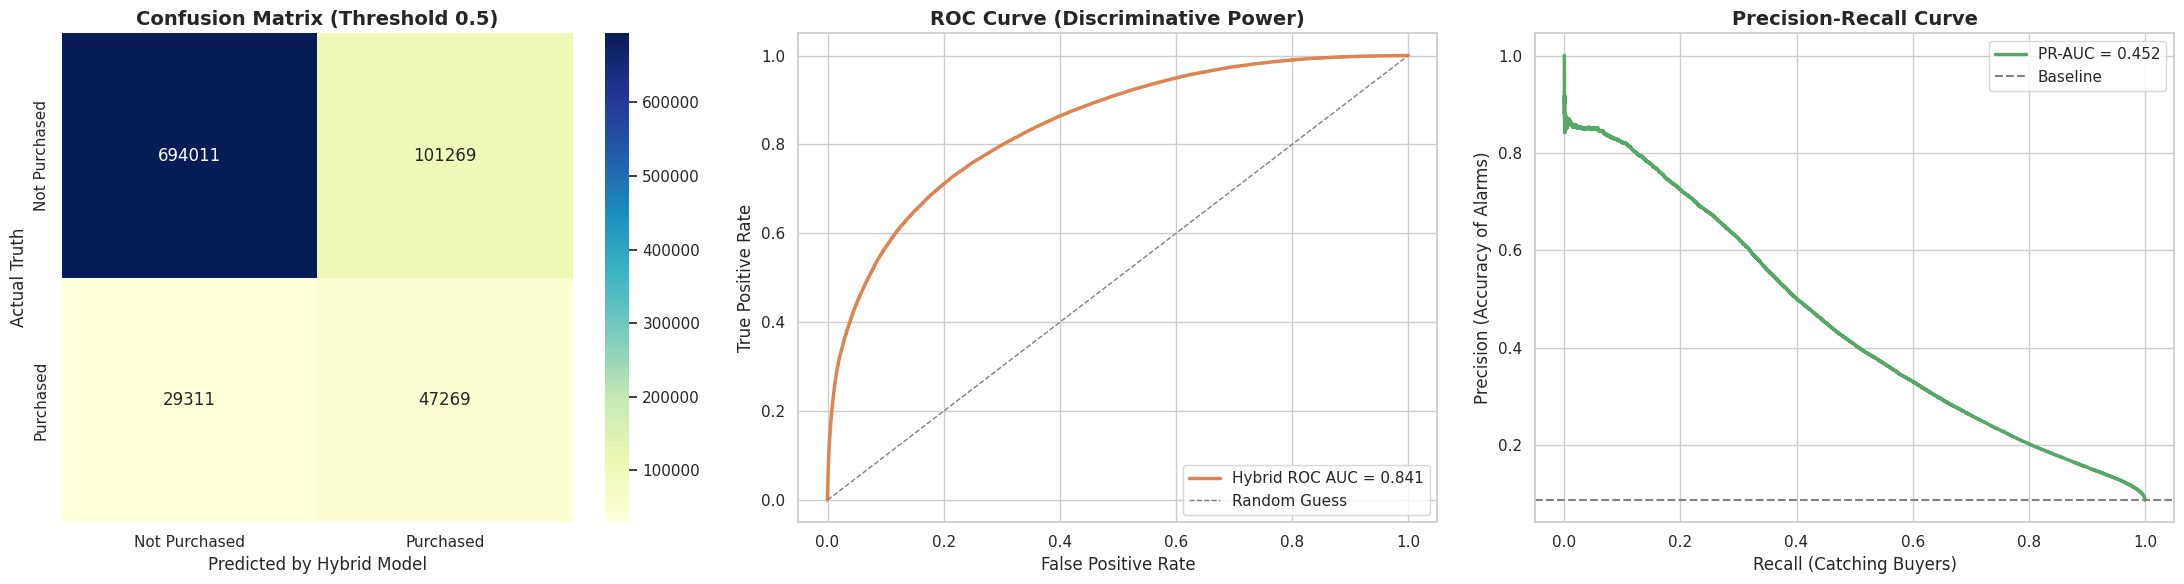


🧠 PHASE 5: HYBRID FEATURE IMPORTANCE (What won the fight?)
📊 Total Importance Share -> Tabular Features: 28.9% | GRU Embeddings: 71.1%



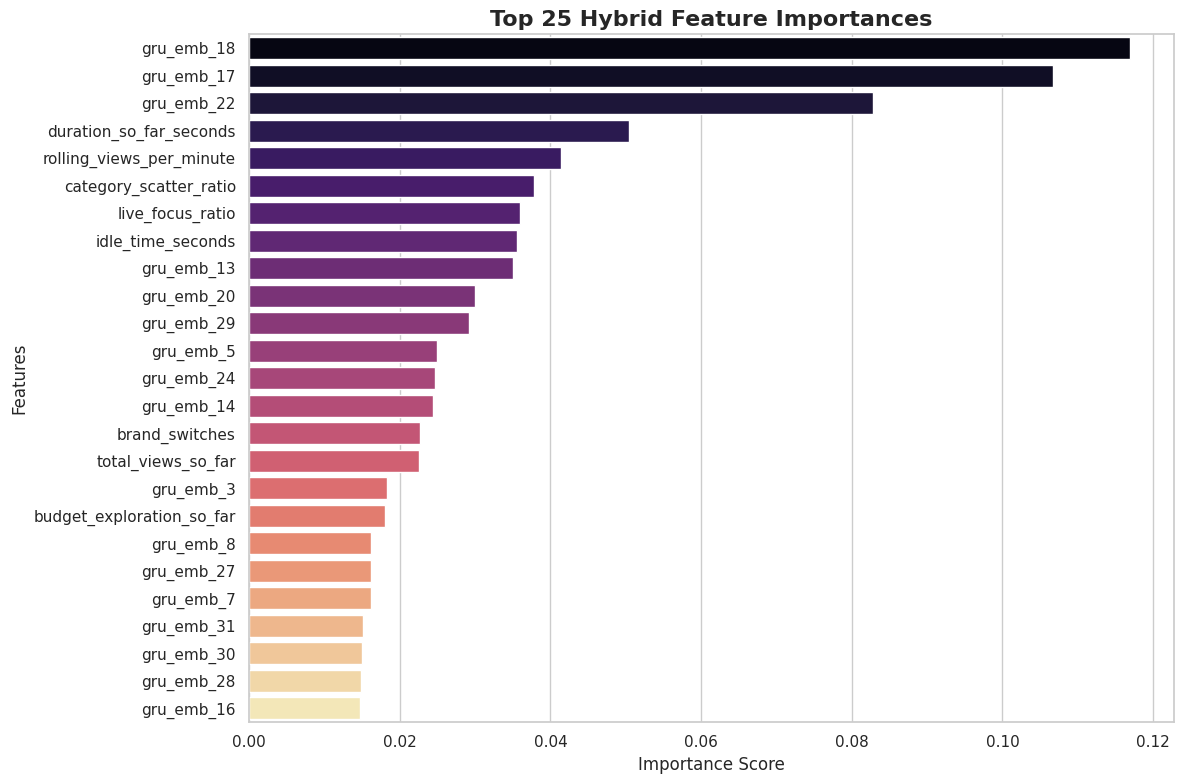

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score, f1_score,
    precision_score, roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from IPython.display import display

print("=" * 70)
print("⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA")
print("=" * 70)

# 1. Ensure No Leakage by Splitting on Users, not rows
unique_users = training_df['user_session'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_data = training_df[training_df['user_session'].isin(train_users)].copy()
test_data  = training_df[training_df['user_session'].isin(test_users)].copy()

# 2. Separate Features and Target
# Drop columns that shouldn't be trained on
cols_to_drop = ['user_session', 'snapshot_label', 'target_purchase']
features = [col for col in training_df.columns if col not in cols_to_drop]

X_train = train_data[features]
y_train = train_data['target_purchase']
X_test  = test_data[features]
y_test  = test_data['target_purchase']

# 3. Calculate class imbalance weight
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ Total Features: {len(features)} (Tabular + GRU Embeddings)")
print(f"✅ Training Snapshots: {X_train.shape[0]:,}")
print(f"✅ Testing Snapshots : {X_test.shape[0]:,}")
print(f"✅ Class Weight Computed: {imbalance_weight:.2f}")


print("\n" + "=" * 70)
print("🚀 PHASE 2: TRAINING THE HYBRID XGBOOST")
print("=" * 70)

# Initializing a robust XGBoost Model with GPU support
hybrid_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,                  # Keep tree depth moderate to balance tabular & deep features
    learning_rate=0.05,
    colsample_bytree=0.7,         # Forces model to mix GRU and Tabular features
    subsample=0.8,
    reg_alpha=0.5,                # L1 regularization to ignore useless GRU dimensions
    reg_lambda=2.0,               # L2 regularization
    scale_pos_weight=imbalance_weight * 0.7, # Slightly reduced to protect precision
    random_state=42,
    tree_method='hist',
    device='cuda',                # GPU Acceleration
    eval_metric='auc'
)

print("Training in progress... (Combining tabular logic with GRU intuition)")
hybrid_xgb.fit(X_train, y_train)
print("✅ Hybrid Model Trained Successfully!")


print("\n" + "=" * 70)
print("📈 PHASE 3: METRICS & CLASSIFICATION REPORT (Threshold = 0.5)")
print("=" * 70)

y_pred = hybrid_xgb.predict(X_test)
y_probs = hybrid_xgb.predict_proba(X_test)[:, 1]

print("📝 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

print("\n🚀 CORE METRICS:")
print(f"-> Accuracy          : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"-> Recall   (Buyers) : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"-> Precision(Buyers) : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"-> F1-Score          : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"-> ROC-AUC Score     : {roc_auc_score(y_test, y_probs):.4f}")
print(f"-> PR-AUC Score      : {average_precision_score(y_test, y_probs):.4f}")


print("\n" + "=" * 70)
print("🎨 PHASE 4: VISUALIZING THE PERFORMANCE")
print("=" * 70)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Threshold 0.5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted by Hybrid Model'); axes[0].set_ylabel('Actual Truth')

# Graph 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'Hybrid ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', label='Random Guess')
axes[1].set_title('ROC Curve (Discriminative Power)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Graph 3: Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
axes[2].plot(recalls, precisions, color='#55A868', lw=2.5, label=f'PR-AUC = {pr_auc:.3f}')
axes[2].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall (Catching Buyers)'); axes[2].set_ylabel('Precision (Accuracy of Alarms)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("🧠 PHASE 5: HYBRID FEATURE IMPORTANCE (What won the fight?)")
print("=" * 70)

# Calculate feature importances
feat_imp = pd.Series(hybrid_xgb.feature_importances_, index=features).sort_values(ascending=False)

# Analyze Tabular vs GRU contribution
gru_cols = [col for col in features if 'gru_emb' in col]
tab_cols = [col for col in features if 'gru_emb' not in col]

gru_importance = feat_imp[gru_cols].sum() * 100
tab_importance = feat_imp[tab_cols].sum() * 100

print(f"📊 Total Importance Share -> Tabular Features: {tab_importance:.1f}% | GRU Embeddings: {gru_importance:.1f}%\n")

# Plot Top 25 Features
plt.figure(figsize=(12, 8))
top_n = 25
sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='magma')
plt.title(f'Top {top_n} Hybrid Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedGroupKFold
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score, f1_score,
    precision_score, roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from IPython.display import display

print("=" * 70)
print("⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA")
print("=" * 70)

unique_users = training_df['user_session'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_data = training_df[training_df['user_session'].isin(train_users)].copy()
test_data  = training_df[training_df['user_session'].isin(test_users)].copy()

cols_to_drop = ['user_session', 'snapshot_label', 'target_purchase']
features = [col for col in training_df.columns if col not in cols_to_drop]

X_train = train_data[features]
y_train = train_data['target_purchase']
groups_train = train_data['user_session'] # 🌟 SUPER IMPORTANT FOR CV LEAKAGE PREVENTION

X_test  = test_data[features]
y_test  = test_data['target_purchase']

imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ Total Features: {len(features)} (Tabular + GRU Embeddings)")
print(f"✅ Training Snapshots: {X_train.shape[0]:,}")
print(f"✅ Testing Snapshots : {X_test.shape[0]:,}")
print(f"✅ Class Weight Computed: {imbalance_weight:.2f}")


print("\n" + "=" * 70)
print("🚀 PHASE 2: ADVANCED HYPERPARAMETER TUNING (Group-Aware)")
print("=" * 70)

# The Search Space (Range of Hyperparameters)
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.6, 0.7, 0.8],  # Force mixing of GRU & Tabular
    'subsample': [0.7, 0.8, 0.9],
    'reg_alpha': [0.1, 0.5, 1.0],         # L1 Regularization
    'reg_lambda': [1.0, 2.0, 5.0],        # L2 Regularization
    'scale_pos_weight': [imbalance_weight * 0.5, imbalance_weight * 0.75, imbalance_weight]
}

# Leakage-Free CV
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='auc'
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,               # Adjust this based on how much time you have
    scoring='average_precision', # Optimize for PR-AUC to keep False Positives in check
    cv=sgkf,
    verbose=2,
    random_state=42,
    n_jobs=1
)

print(f"Starting Group-Aware CV Tuning (Trying {random_search.n_iter} combinations)...")
start_time = time.time()
random_search.fit(X_train, y_train, groups=groups_train)

print(f"\n✅ Tuning Completed in {(time.time() - start_time)/60:.2f} minutes!")
hybrid_xgb = random_search.best_estimator_
print(f"🏆 WINNING HYPERPARAMETERS:\n{random_search.best_params_}")


print("\n" + "=" * 70)
print("🎯 PHASE 3: OPTIMAL THRESHOLD DISCOVERY (Max Recall via F2-Score)")
print("=" * 70)

y_probs = hybrid_xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Beta = 2 heavily penalizes False Negatives (Missed Buyers)
beta = 2
f2_scores = (1 + beta**2) * (precisions[:-1] * recalls[:-1]) / ((beta**2 * precisions[:-1]) + recalls[:-1])
f2_scores = np.nan_to_num(f2_scores)

optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"✨ MATHEMATICALLY OPTIMAL THRESHOLD FOUND: {optimal_threshold:.4f}\n")

# Apply the new threshold
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)


print("\n" + "=" * 70)
print("📈 PHASE 4: FINAL METRICS & CLASSIFICATION REPORT")
print("=" * 70)

print(f"📝 DETAILED CLASSIFICATION REPORT (Threshold = {optimal_threshold:.4f}):")
print(classification_report(y_test, y_pred_optimal, target_names=['No Purchase', 'Purchase']))

print("\n🚀 CORE METRICS:")
print(f"-> Accuracy          : {accuracy_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> Recall   (Buyers) : {recall_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> Precision(Buyers) : {precision_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> F1-Score          : {f1_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"-> F2-Score          : {f2_scores[optimal_idx]:.4f}")
print(f"-> ROC-AUC Score     : {roc_auc_score(y_test, y_probs):.4f}")
print(f"-> PR-AUC Score      : {average_precision_score(y_test, y_probs):.4f}")


print("\n" + "=" * 70)
print("🎨 PHASE 5: VISUALIZING THE PERFORMANCE")
print("=" * 70)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Graph 1: Optimized Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'], ax=axes[0])
axes[0].set_title(f'Optimized Confusion Matrix (Thresh={optimal_threshold:.3f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted by Hybrid Model'); axes[0].set_ylabel('Actual Truth')

# Graph 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2.5, label=f'Hybrid ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', label='Random Guess')
axes[1].set_title('ROC Curve (Discriminative Power)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Graph 3: Precision-Recall Curve with Optimal Point
pr_auc = average_precision_score(y_test, y_probs)
axes[2].plot(recalls, precisions, color='#55A868', lw=2.5, label=f'PR-AUC = {pr_auc:.3f}')
axes[2].scatter(recalls[optimal_idx], precisions[optimal_idx], color='red', s=100, zorder=5,
                label=f'Opt Point (Recall={recalls[optimal_idx]:.2f})')
axes[2].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve & Opt Threshold', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall (Catching Buyers)'); axes[2].set_ylabel('Precision (Accuracy of Alarms)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("🧠 PHASE 6: HYBRID FEATURE IMPORTANCE")
print("=" * 70)

feat_imp = pd.Series(hybrid_xgb.feature_importances_, index=features).sort_values(ascending=False)

gru_cols = [col for col in features if 'gru_emb' in col]
tab_cols = [col for col in features if 'gru_emb' not in col]

gru_importance = feat_imp[gru_cols].sum() * 100
tab_importance = feat_imp[tab_cols].sum() * 100

print(f"📊 Total Importance Share -> Tabular Features: {tab_importance:.1f}% | GRU Embeddings: {gru_importance:.1f}%\n")

plt.figure(figsize=(12, 8))
top_n = 25
sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='magma')
plt.title(f'Top {top_n} Hybrid Feature Importances (Tuned)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

⚙️ PHASE 1: USER-BASED SPLIT FOR HYBRID DATA
